<a href="https://colab.research.google.com/github/andreydeps/estudo-ci-ncia-de-dados/blob/main/An%C3%A1lise_Automatizada_de_Pol%C3%ADtica_Monet%C3%A1ria_com_Python_e_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install -q -U google-generativeai

In [19]:
# --- CÉLULA DE CONFIGURAÇÃO ---
import requests
import pandas as pd
import google.generativeai as genai
from google.colab import userdata

# Configurando o Gemini
minha_chave = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=minha_chave)
model = genai.GenerativeModel('gemini-2.5-flash')

# --- CÉLULA DE EXECUÇÃO ---
# Agora você busca os dados (usando a lógica de data inicial que funcionou)
data_inicio = "01/01/2024"
url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json&dataInicial={data_inicio}"

resposta = requests.get(url)
if resposta.status_code == 200:
    df_ipca = pd.DataFrame(resposta.json())
    print("Dados do IPCA carregados com sucesso!")

Dados do IPCA carregados com sucesso!


In [2]:
# Transformamos a lista de dicionários em um DataFrame (Tabela)
df_selic = pd.DataFrame(dados_brutos)

# O Banco Central manda os números como texto (ex: "10.75")
# Precisamos avisar ao Python que isso é um número decimal (float)
df_selic['valor'] = df_selic['valor'].astype(float)

# Exibe as primeiras linhas da tabela organizada
print("Tabela organizada com Pandas:")
display(df_selic)

Tabela organizada com Pandas:


,data,valor
0,20/04/2026,0.054266
1,22/04/2026,0.054266
2,23/04/2026,0.054266
3,24/04/2026,0.054266
4,27/04/2026,0.054266
5,28/04/2026,0.054266
6,29/04/2026,0.054266
7,30/04/2026,0.053400
8,04/05/2026,0.053400
9,05/05/2026,0.053400


In [13]:
import requests
import pandas as pd

# Definimos as séries e o período real que queremos
data_inicio = "01/01/2024"
series = {
    'Selic': 432,
    'IPCA': 433
}

lista_dataframes = []

for nome, codigo in series.items():
    # Usamos o endpoint de 'dados' com filtro de data inicial
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados?formato=json&dataInicial={data_inicio}"

    resposta = requests.get(url)

    # Se a resposta for 200 (OK), processamos
    if resposta.status_code == 200:
        dados = resposta.json()
        print(f"Série {nome}: {len(dados)} meses encontrados desde {data_inicio}.")

        df_temp = pd.DataFrame(dados)

        # Garante a conversão e renomeia
        df_temp[nome] = df_temp['valor'].astype(float)
        df_temp = df_temp[['data', nome]].set_index('data')

        lista_dataframes.append(df_temp)
    else:
        print(f"Erro ao acessar série {nome}: Status {resposta.status_code}")

# Concatenando os resultados
if len(lista_dataframes) == 2:
    df_final = pd.concat(lista_dataframes, axis=1)
    print("\nSucesso! Tabela de 2024 a 2026:")
    display(df_final)

Série Selic: 899 meses encontrados desde 01/01/2024.
Série IPCA: 27 meses encontrados desde 01/01/2024.

Sucesso! Tabela de 2024 a 2026:


,Selic,IPCA
data,,
01/01/2024,11.75,0.42
02/01/2024,11.75,NaN
03/01/2024,11.75,NaN
04/01/2024,11.75,NaN
05/01/2024,11.75,NaN
...,...,...
13/06/2026,14.50,NaN
14/06/2026,14.50,NaN
15/06/2026,14.50,NaN


In [20]:
# Criando o prompt com os dados injetados
prompt = f"""
Faça uma análise da evolução da Selic e do IPCA, e traga indicativos de como isso
refletiu nas opções de investimento para pessoas com perfil de investimentos
mais conservadores e outras que assumem mais riscos.

Dados para análise:
{df_final.to_string()}
"""

# Enviando o prompt para a IA e guardando a resposta
response = model.generate_content(prompt)

# Exibindo o resultado final
print(response.text)

A análise da evolução da Selic e do IPCA, conforme os dados fornecidos de janeiro de 2024 a junho de 2026, revela um cenário dinâmico na economia brasileira, com impactos distintos nas estratégias de investimento para diferentes perfis.

Vamos detalhar a evolução de cada indicador e, em seguida, como isso se refletiu nas opções de investimento.

---

### Análise da Evolução da Selic e do IPCA

**1. Evolução da Taxa Selic:**

A taxa Selic, a taxa básica de juros da economia, é um instrumento do Banco Central para controlar a inflação. Sua movimentação afeta diretamente o custo do dinheiro, o crédito e a rentabilidade de diversos investimentos.

*   **Início de 2024 (Jan a Mar):** A Selic inicia o período em **11.75%** ao ano e apresenta uma trajetória de queda gradual. Em fevereiro, vai para **11.25%**, e em março, para **10.75%**. Esta fase indica um movimento de flexibilização monetária, possivelmente devido a uma expectativa de controle inflacionário ou desaceleração econômica.
*   *

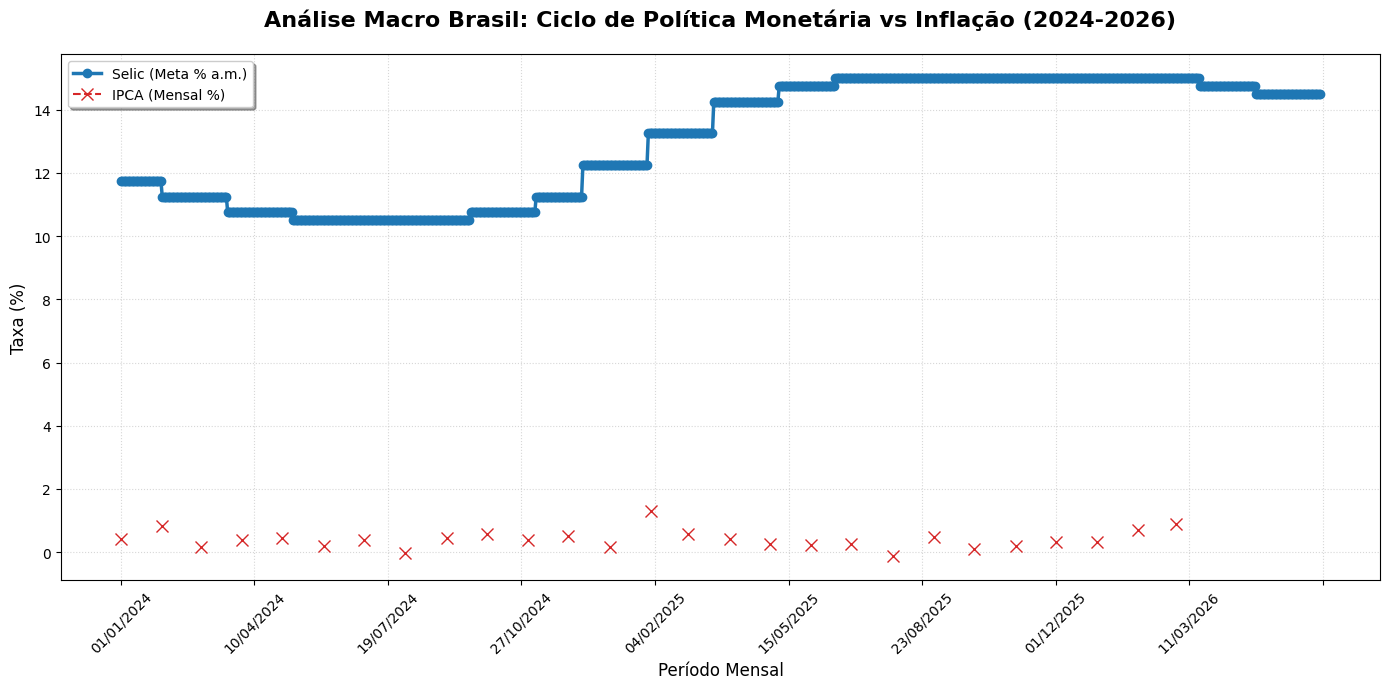

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Configurando o tamanho e estilo do gráfico
plt.figure(figsize=(14, 7))
ax = plt.gca() # Pega os eixos atuais para ajustes finos

# 2. Plotagem das Séries
# Selic com linha contínua e círculos
plt.plot(df_final.index, df_final['Selic'],
         label='Selic (Meta % a.m.)',
         marker='o',
         markersize=6,
         linewidth=2.5,
         color='#1f77b4')

# IPCA com linha tracejada e 'x'
plt.plot(df_final.index, df_final['IPCA'],
         label='IPCA (Mensal %)',
         marker='x',
         markersize=8,
         linestyle='--',
         color='#d62728')

# 3. Ajuste do Eixo X (Para evitar a poluição visual que apareceu antes)
# Mostra apenas um número razoável de datas (labels) no eixo X
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))

# 4. Embelezamento (Padrão Analista Sênior)
plt.title('Análise Macro Brasil: Ciclo de Política Monetária vs Inflação (2024-2026)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Período Mensal', fontsize=12)
plt.ylabel('Taxa (%)', fontsize=12)

# Adiciona uma grade sutil para facilitar a leitura dos valores
plt.grid(True, linestyle=':', alpha=0.5)

# Legenda bem posicionada
plt.legend(loc='upper left', frameon=True, shadow=True)

# Rotaciona as datas para melhor leitura
plt.xticks(rotation=45)

# 5. Exibição com ajuste de layout
plt.tight_layout()
plt.show()